El objetivo es segmentar a los clientes con base a distintas características.

In [19]:
import pandas as pd
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns



BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "northwind.db"

conn = sqlite3.connect(DB_PATH)

Conexión con la base de datos Northwind hecha.

In [20]:
query = ''' SELECT c.CustomerName as NombreCliente, SUM(od.Quantity) as UnidadesCompradas, sum(od.Quantity * p.Price) AS Monto, 
        count(DISTINCT o.OrderID) as NumeroDeOrdenes, AVG(od.Quantity * p.Price) AS TicketPromedio, 
        c.Country as Pais, COUNT(DISTINCT p.CategoryID) AS DiversidadCategorias FROM Customers c
        JOIN Orders o ON c.CustomerID = o.CustomerID
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products P ON od.ProductID = p.ProductID
        GROUP BY c.CustomerName
        ORDER BY Monto DESC  
'''

dataset = pd.read_sql_query(query, conn)
print(dataset) 

                         NombreCliente  UnidadesCompradas     Monto  \
0                         Ernst Handel               1418  35631.21   
1                       Mère Paillarde                422  23362.60   
2                   Save-a-lot Markets                775  22500.06   
3           Rattlesnake Canyon Grocery                573  18421.42   
4                           QUICK-Stop                839  18178.80   
..                                 ...                ...       ...   
69              Océano Atlántico Ltda.                 24    399.00   
70                     Du monde entier                 13    336.00   
71          Centro comercial Moctezuma                 11    126.00   
72  Ana Trujillo Emparedados y helados                  6    111.00   
73                      Franchi S.p.A.                  2     62.46   

    NumeroDeOrdenes  TicketPromedio       Pais  DiversidadCategorias  
0                10     1018.034571    Austria                     8  
1    

Ya tenemos nuestro data set cargado, ahora hay que verificar que esté limpio.

In [21]:
print(dataset.info())
print(dataset.index.duplicated().any())
print(dataset.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NombreCliente         74 non-null     object 
 1   UnidadesCompradas     74 non-null     int64  
 2   Monto                 74 non-null     float64
 3   NumeroDeOrdenes       74 non-null     int64  
 4   TicketPromedio        74 non-null     float64
 5   Pais                  74 non-null     object 
 6   DiversidadCategorias  74 non-null     int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 4.2+ KB
None
False
NombreCliente           0
UnidadesCompradas       0
Monto                   0
NumeroDeOrdenes         0
TicketPromedio          0
Pais                    0
DiversidadCategorias    0
dtype: int64


El data frame está limpio. Ahora como queremos segmentar a nuestros clientes de acuerdo a sus características podemos pensar en algún algorítmo de Machine Learning, en este caso de aprendizaje no supervisado, concretamente de clustering. Como pudímos ver en el EDA varias de estas variables aleatorias tienen multiples outliers por lo que algunos modelos que son sensibles a estos pueden verse afectados. En principio DBSCAN debería hacer un buen trabajo con los valores atípcos porque los maneja como ruído aunque si las variables aleatorias están muy correlacionadas pueden influír en el modelo negativamente. Antes de DBSCAN veremos qué tan correlacionadas están entre sí y si es necesario aplicar algún algorítmo PCA para agrupar las variables según que tan relacionadas estén.

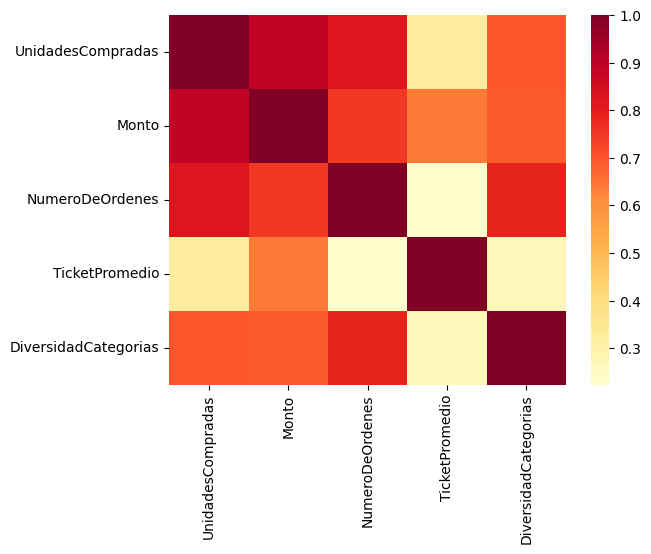

In [37]:
matriz_corr = dataset.corr(numeric_only=True)

sns.heatmap(matriz_corr, cmap="YlOrRd")
plt.show()

En el heatmap podemos observar que que  variable Unidades compradas tiene una alta correlación con Monto y con Número de ordenes, esto afectrá al modelo pues le dara más peso a la magnitud de compra que a otras actegorías. En este escenario es coveniente aplicar un algorítmo de PCA para agrupar estas variables antes de usar DBSCAN.